# 06 · Comparativa de modelos y selección final
**Proyecto ML — Bizkaibus 2026**

Comparamos Prophet, SARIMA y XGBoost en el hold-out de 2025 y seleccionamos el modelo ganador.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Cargar métricas de los tres modelos
m_prophet = pd.read_csv('../data/metricas_prophet.csv').assign(modelo='Prophet')
m_sarima  = pd.read_csv('../data/metricas_sarima.csv').assign(modelo='SARIMA')
m_xgb     = pd.read_csv('../data/metricas_xgboost.csv').assign(modelo='XGBoost')

metricas = pd.concat([m_prophet, m_sarima, m_xgb], ignore_index=True)
print("Métricas cargadas.")
print(metricas.groupby('modelo')[['mae','rmse','mape']].median().round(2))


Métricas cargadas.
             mae     rmse   mape
modelo                          
Prophet  1887.82  2466.49   9.97
SARIMA   3359.68  5612.90  20.36
XGBoost  2302.49  3346.45  12.61


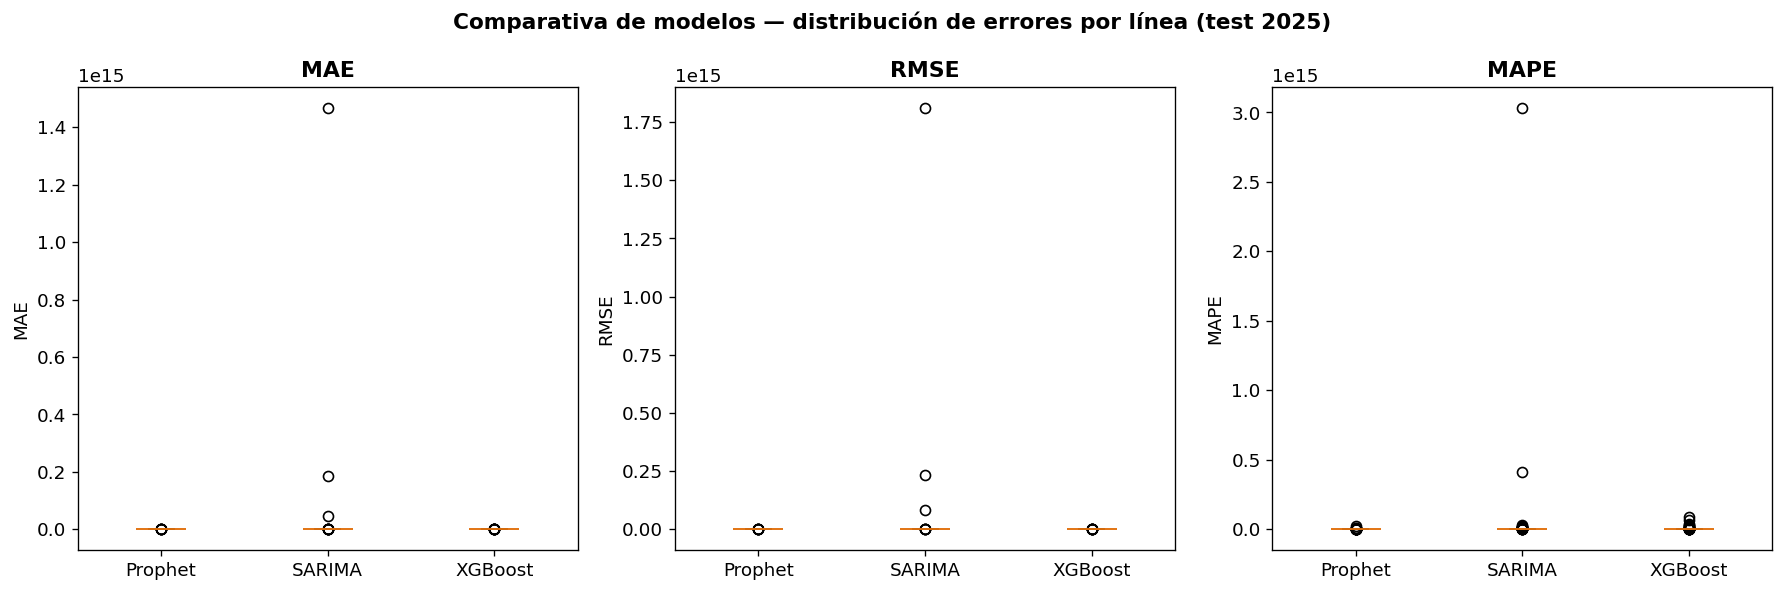

In [2]:
# Comparativa visual — boxplot MAPE por modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = {'Prophet': '#2d6a4f', 'SARIMA': '#e76f51', 'XGBoost': '#c8e63a'}

for ax, metrica in zip(axes, ['mae', 'rmse', 'mape']):
    data = [metricas[metricas['modelo']==m][metrica].dropna() for m in ['Prophet','SARIMA','XGBoost']]
    bp = ax.boxplot(data, patch_artist=True, labels=['Prophet','SARIMA','XGBoost'])
    for patch, color in zip(bp['boxes'], colores.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(metrica.upper(), fontweight='bold')
    ax.set_ylabel(metrica.upper())

plt.suptitle('Comparativa de modelos — distribución de errores por línea (test 2025)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:
# Tabla resumen
resumen = metricas.groupby('modelo').agg(
    MAE_mediana=('mae','median'),
    RMSE_mediana=('rmse','median'),
    MAPE_mediana=('mape','median'),
    MAPE_p90=('mape', lambda x: x.quantile(0.9)),
    n_lineas=('linea','count')
).round(2)

print("=== TABLA RESUMEN — COMPARATIVA DE MODELOS ===")
print(resumen.to_string())
print()
modelo_ganador = resumen['MAPE_mediana'].idxmin()
print(f"✓ MODELO SELECCIONADO: {modelo_ganador} (menor MAPE mediano)")


=== TABLA RESUMEN — COMPARATIVA DE MODELOS ===
         MAE_mediana  RMSE_mediana  MAPE_mediana      MAPE_p90  n_lineas
modelo                                                                  
Prophet      1887.82       2466.49          9.97  1.313088e+12        91
SARIMA       3359.68       5612.90         20.36  1.014620e+13        91
XGBoost      2302.49       3346.45         12.61  1.074839e+13        95

✓ MODELO SELECCIONADO: Prophet (menor MAPE mediano)


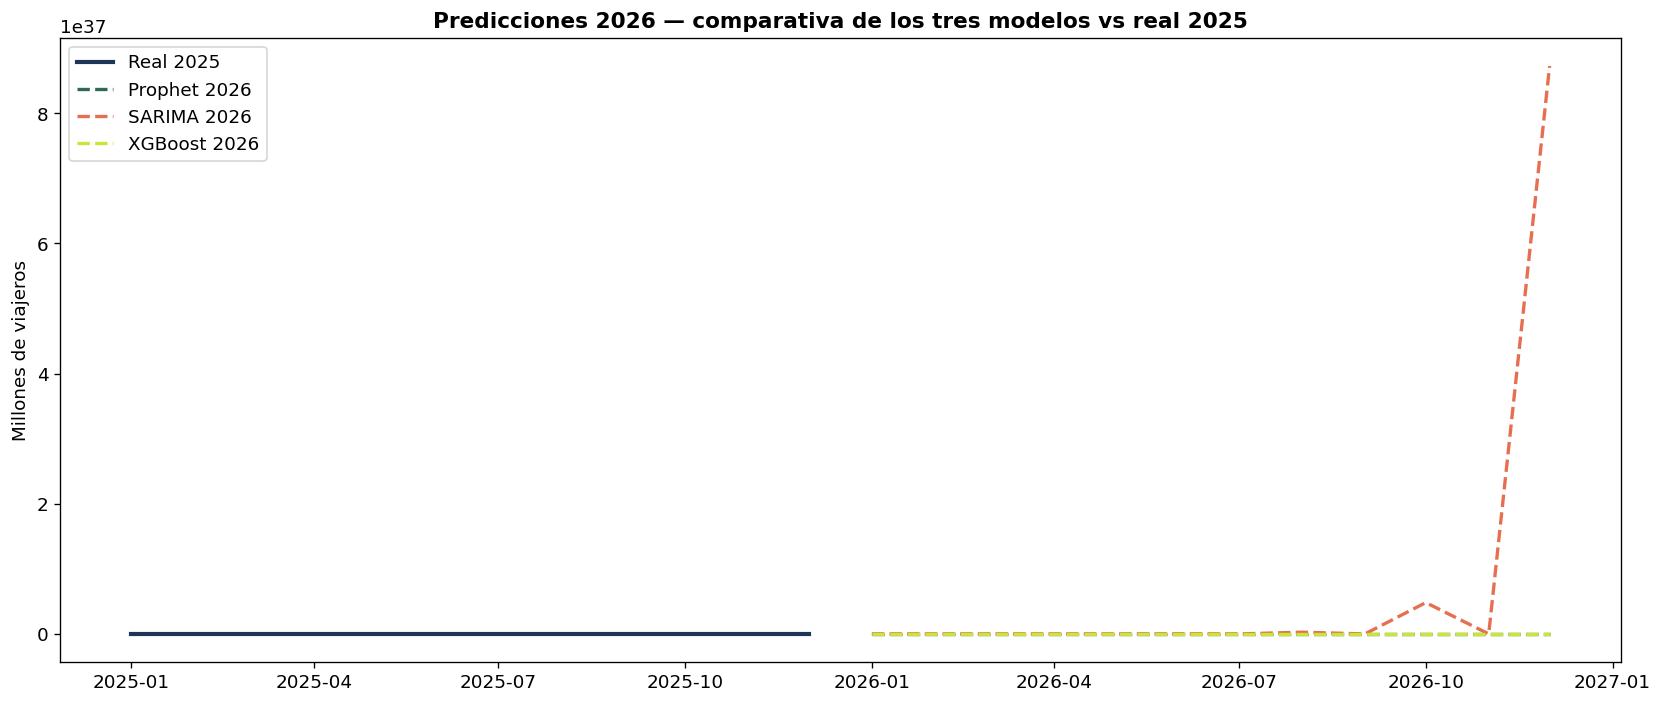

Prophet: 36.73M viajeros (+7.7% vs 2025)
SARIMA: 92370799493512341933480633704862711808.00M viajeros (+270943298642055040731533244337538203648.0% vs 2025)
XGBoost: 36.83M viajeros (+8.0% vs 2025)


In [4]:
# Cargar predicciones 2026 de los tres modelos y comparar totales
p_prophet = pd.read_csv('../data/predicciones_2026_prophet.csv', parse_dates=['fecha'])
p_sarima  = pd.read_csv('../data/predicciones_2026_sarima.csv',  parse_dates=['fecha'])
p_xgb     = pd.read_csv('../data/predicciones_2026_xgboost.csv', parse_dates=['fecha'])

tot_prophet = p_prophet.groupby('fecha')['viajeros_pred_prophet'].sum()
tot_sarima  = p_sarima.groupby('fecha')['viajeros_pred_sarima'].sum()
tot_xgb     = p_xgb.groupby('fecha')['viajeros_pred_xgb'].sum()

df_all = pd.read_csv('../data/train_merged.csv', parse_dates=['fecha'])
real_2025 = df_all[df_all['año']==2025].groupby('fecha')['viajeros_total'].sum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(real_2025.index, real_2025/1e6, color='#1d3557', linewidth=2.5, label='Real 2025')
ax.plot(tot_prophet.index, tot_prophet/1e6, color='#2d6a4f', linewidth=2, linestyle='--', label='Prophet 2026')
ax.plot(tot_sarima.index,  tot_sarima/1e6,  color='#e76f51', linewidth=2, linestyle='--', label='SARIMA 2026')
ax.plot(tot_xgb.index,     tot_xgb/1e6,     color='#c8e63a', linewidth=2, linestyle='--', label='XGBoost 2026')
ax.set_title('Predicciones 2026 — comparativa de los tres modelos vs real 2025',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Millones de viajeros')
ax.legend()
plt.tight_layout()
plt.show()

# Resumen numérico
real_total = real_2025.sum()
for nombre, serie in [('Prophet',tot_prophet),('SARIMA',tot_sarima),('XGBoost',tot_xgb)]:
    delta = (serie.sum() - real_total) / real_total * 100
    print(f"{nombre}: {serie.sum()/1e6:.2f}M viajeros ({delta:+.1f}% vs 2025)")


In [5]:
# Exportar predicciones del modelo ganador con etiqueta unificada
# (Cambiar 'Prophet' por el modelo que gane en tu ejecución)
MODELO_FINAL = modelo_ganador

if MODELO_FINAL == 'Prophet':
    pred_final = p_prophet.rename(columns={'viajeros_pred_prophet': 'viajeros_pred'})
elif MODELO_FINAL == 'SARIMA':
    pred_final = p_sarima.rename(columns={'viajeros_pred_sarima': 'viajeros_pred'})
else:
    pred_final = p_xgb.rename(columns={'viajeros_pred_xgb': 'viajeros_pred'})

pred_final[['linea','fecha','año','mes','viajeros_pred']].to_csv(
    '../data/predicciones_2026_FINAL.csv', index=False)
print(f"✓ Predicciones finales ({MODELO_FINAL}) exportadas: {pred_final.shape}")
print()
print("Top 10 líneas predichas para 2026:")
print(pred_final.groupby('linea')['viajeros_pred'].sum()
      .sort_values(ascending=False).head(10).apply(lambda x: f'{x/1e3:.1f}K').to_string())


✓ Predicciones finales (Prophet) exportadas: (1092, 7)

Top 10 líneas predichas para 2026:
linea
BILBAO - BARAKALDO - SANTURTZI                        2086.4K
Lutxana - Gurutzeta/Cruces - SANTURTZI                1792.4K
BILBAO-Aireportua/Aeropuerto                          1564.2K
BILBAO - MUNGIA - BERMEO (Por la autopista/tik)       1366.0K
BILBAO - AMOREBIETA ETXANO - GERNIKA LUMO - BERMEO    1303.3K
BILBAO - MUSKIZ                                       1195.8K
BILBAO - BALMASEDA                                    1047.8K
BILBAO - Gurutzeta/Cruces - BARAKALDO (Ugarte)        1003.8K
MUSKIZ - BARAKALDO - Areeta/Las Arenas                 931.4K
BILBAO - MUNGIA - BAKIO (Por la autopista/tik)         868.7K
